In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/asdasdasasdas/garbage-classification/one-indexed-files-notrash_val.txt
/kaggle/input/datasets/asdasdasasdas/garbage-classification/one-indexed-files-notrash_train.txt
/kaggle/input/datasets/asdasdasasdas/garbage-classification/zero-indexed-files.txt
/kaggle/input/datasets/asdasdasasdas/garbage-classification/one-indexed-files.txt
/kaggle/input/datasets/asdasdasasdas/garbage-classification/one-indexed-files-notrash_test.txt
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/metal/metal375.jpg
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/metal/metal341.jpg
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/metal/metal374.jpg
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/metal/metal383.jpg
/kaggle/input/datasets/asdasdasasdas/garbage-class

In [2]:
import numpy as np 
import pandas as pd 
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid
import matplotlib.pyplot as plt 


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.1),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [4]:
DATA_DIR = "/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification"  # Path to unzipped dataset folder
train_dataset = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
test_dataset = datasets.ImageFolder(root=DATA_DIR, transform=test_transform)
Classes = train_dataset.classes
num_classes = len(Classes)
n = len(train_dataset)
indices = np.random.permutation(n)
split = int(0.8 * n)
train_inx, test_inx = indices[:split], indices[split:]
train_subset = Subset(train_dataset, train_inx)
test_subset = Subset(test_dataset, test_inx)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False, num_workers=2)

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 1. Load Pretrained Model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 2. Freeze ALL base layers first
for param in model.parameters():
    param.requires_grad = False

# 3. Replace final FC layer FIRST (new layer has requires_grad=True by default)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# 4. Unfreeze layer4 explicitly (fixed typo: 'param' instead of 'parma')
for param in model.layer4.parameters():
    param.requires_grad = True

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 0.0001}, # Fine-tune backbone
    {'params': model.fc.parameters(),     'lr': 0.001}   # Fast-learn head
])

# 6. Training & Validation Loop
epochs = 10
best_acc = 0.0

for epoch in range(epochs):
    print(f"\nEpoch: {epoch + 1} / {epochs}")
    print("-" * 25)

    # --- Training Phase ---
    model.train()
    running_loss, running_corr = 0.0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, pred = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corr += torch.sum(pred == labels.data)

    epoch_loss = running_loss / len(train_subset)
    epoch_acc = running_corr.double() / len(train_subset)
    print(f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

    # --- Validation Phase ---
    model.eval()
    val_loss, val_corr = 0.0, 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, pred = torch.max(outputs, 1)

            val_loss += loss.item() * inputs.size(0)
            val_corr += torch.sum(pred == labels.data)

    val_loss = val_loss / len(test_subset)
    val_acc = val_corr.double() / len(test_subset)
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    # Save checkpoint if accuracy improves
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "waste_classifier_resnet18.pth")
        print("--> Saved best model checkpoint.")

print(f"\nTraining Complete. Best Validation Accuracy: {best_acc:.4f}")


Epoch: 1 / 10
-------------------------
Train Loss: 0.8087 | Train Acc: 0.7036
Val Loss:   0.4455 | Val Acc:   0.8478
--> Saved best model checkpoint.

Epoch: 2 / 10
-------------------------
Train Loss: 0.3683 | Train Acc: 0.8738
Val Loss:   0.3756 | Val Acc:   0.8735
--> Saved best model checkpoint.

Epoch: 3 / 10
-------------------------
Train Loss: 0.1944 | Train Acc: 0.9352
Val Loss:   0.3329 | Val Acc:   0.8854
--> Saved best model checkpoint.

Epoch: 4 / 10
-------------------------
Train Loss: 0.1333 | Train Acc: 0.9649
Val Loss:   0.2972 | Val Acc:   0.8992
--> Saved best model checkpoint.

Epoch: 5 / 10
-------------------------
Train Loss: 0.0821 | Train Acc: 0.9787
Val Loss:   0.3115 | Val Acc:   0.8992

Epoch: 6 / 10
-------------------------
Train Loss: 0.0644 | Train Acc: 0.9802
Val Loss:   0.2875 | Val Acc:   0.9150
--> Saved best model checkpoint.

Epoch: 7 / 10
-------------------------
Train Loss: 0.0764 | Train Acc: 0.9713
Val Loss:   0.2950 | Val Acc:   0.9190
--

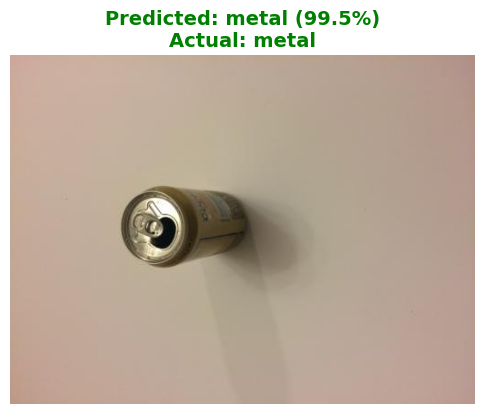

In [7]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

full_dataset = datasets.ImageFolder(root=DATA_DIR)
random_path, true_idx = random.choice(full_dataset.samples)
true_class = Classes[true_idx]

raw_img = Image.open(random_path).convert('RGB')

input_tensor = test_transform(raw_img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = F.softmax(outputs[0], dim=0)
    pred_idx = torch.argmax(probabilities).item()
    confidence = probabilities[pred_idx].item() * 100
    pred_class = Classes[pred_idx]

plt.figure(figsize=(6, 6))
plt.imshow(raw_img)
plt.axis('off')

# Green title if correct, red title if misclassified
title_color = 'green' if pred_class == true_class else 'red'
plt.title(
    f"Predicted: {pred_class} ({confidence:.1f}%)\nActual: {true_class}",
    color=title_color,
    fontsize=14,
    fontweight='bold'
)
plt.show()

In [8]:
import requests
from io import BytesIO
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

def predict_from_url(url, model, class_names, device):
    # Fetch image from web (headers prevent 403 forbidden errors from some servers)
    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers)
    
    if response.status_code != 200:
        print(f"Failed to fetch image. HTTP Status Code: {response.status_code}")
        return

    # Load image from byte stream
    raw_img = Image.open(BytesIO(response.content)).convert('RGB')
    
    # Preprocess tensor (uses validation transforms defined earlier)
    input_tensor = test_transform(raw_img).unsqueeze(0).to(device)
    
    # Model inference
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = F.softmax(outputs[0], dim=0)
        confidence, pred_idx = torch.max(probabilities, dim=0)
        
    pred_class = class_names[pred_idx.item()]
    confidence_score = confidence.item() * 100

    # Plot image and result
    plt.figure(figsize=(5, 5))
    plt.imshow(raw_img)
    plt.axis('off')
    plt.title(f"Predicted: {pred_class} ({confidence_score:.2f}%)", fontsize=14, color="blue")
    plt.show()

    return pred_class, confidence_score

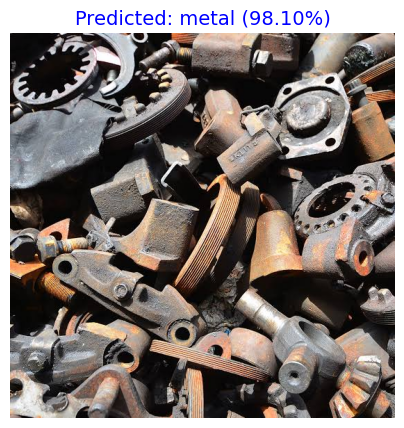

('metal', 98.09973239898682)

In [9]:
# Pass any direct image URL (.jpg / .png)
img_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSEjZfoUUmhv2oio19YA_r7MXkGvd2czOYo9daVkZSc6w&s=10"
predict_from_url(img_url, model, Classes, device)

In [10]:
torch.save(model.state_dict(), "/kaggle/working/resnet18.pth")

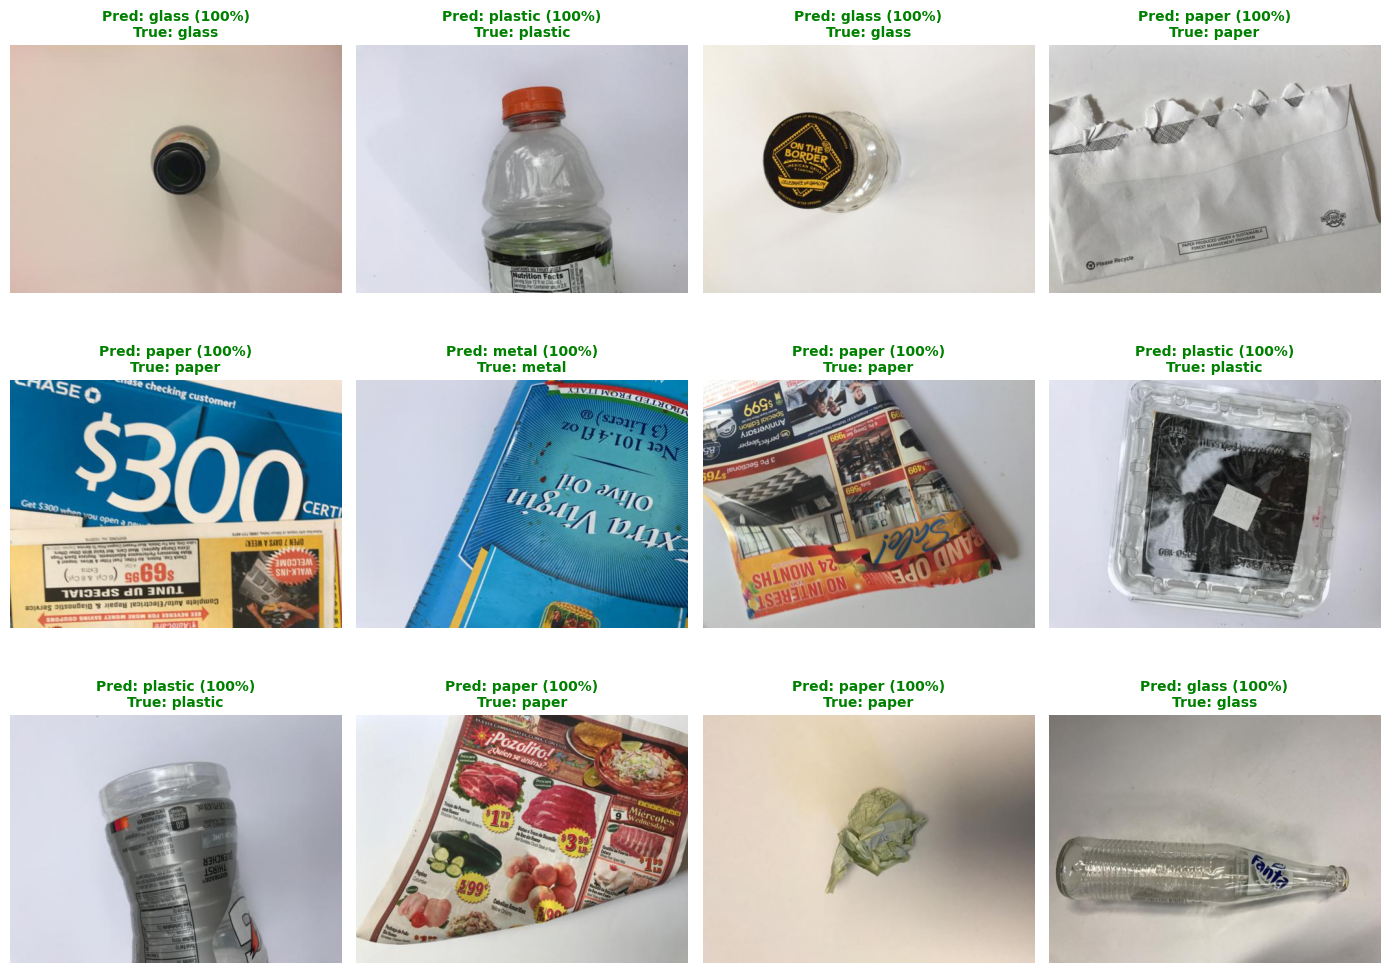

In [11]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import math

def predict_and_show(dataset, model, class_names, device, n=12, cols=4):
    """Randomly samples n images from `dataset`, predicts each, and plots them in a grid."""
    model.eval()
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * 3.5, rows * 3.5))

    for i, idx in enumerate(indices):
        img_path, true_idx = dataset.samples[idx]
        true_class = class_names[true_idx]

        raw_img = Image.open(img_path).convert('RGB')
        input_tensor = test_transform(raw_img).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(input_tensor)
            probs = F.softmax(outputs[0], dim=0)
            pred_idx = torch.argmax(probs).item()
            confidence = probs[pred_idx].item() * 100
            pred_class = class_names[pred_idx]

        plt.subplot(rows, cols, i + 1)
        plt.imshow(raw_img)
        plt.axis('off')
        color = 'green' if pred_class == true_class else 'red'
        plt.title(f"Pred: {pred_class} ({confidence:.0f}%)\nTrue: {true_class}",
                   color=color, fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Run it on 12 random images from the full dataset
predict_and_show(full_dataset, model, Classes, device, n=12, cols=4)

       WASTE CLASSIFICATION RESULTS
Accuracy  : 91.70%
Precision : 92.04%
Recall    : 91.70%
F1 Score  : 91.76%


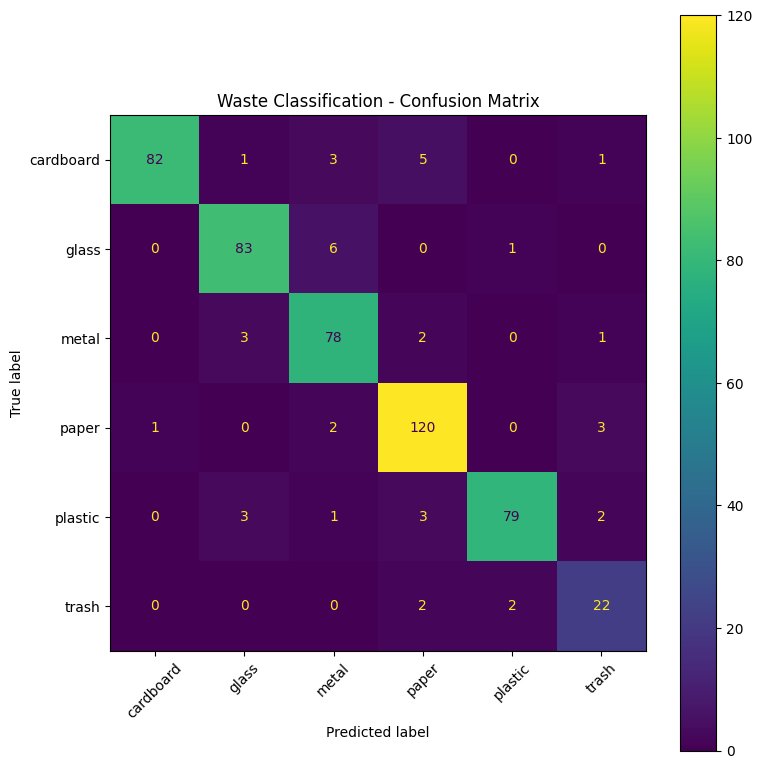

In [12]:
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==========================================
# 1. Evaluate model
# ==========================================

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())


# ==========================================
# 2. Calculate metrics
# ==========================================

accuracy = accuracy_score(all_labels, all_preds)

precision = precision_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)


# ==========================================
# 3. Print results
# ==========================================

print("=" * 45)
print("       WASTE CLASSIFICATION RESULTS")
print("=" * 45)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")

print("=" * 45)


# ==========================================
# 4. Confusion Matrix
# ==========================================

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=Classes
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

ax.set_title("Waste Classification - Confusion Matrix")

plt.tight_layout()
plt.show()

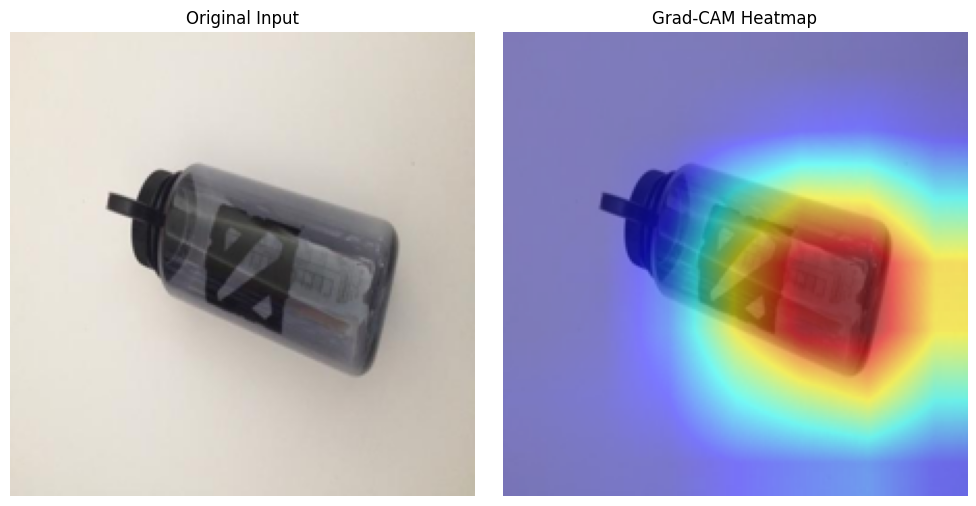

In [15]:
# 1. Install grad-cam inside Kaggle environment
!pip install grad-cam -q

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 2. Define your class mappings (default for Kaggle 6-category waste dataset)
CLASSES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

# 3. Load your model (adjust model class and path to where you saved your weights)
# If saved during your Kaggle session, weights are in '/kaggle/working/'
#model = MyWasteCNN()  # Replace with your model definition
#model.load_state_dict(torch.load('/kaggle/working/best_waste_model.pth'))
model.eval()

# 4. Target Layer Selection (Adjust to your model architecture)
# - Custom CNN: [model.conv_layers[-1]]
# - ResNet: [model.layer4[-1]]
# - EfficientNet / MobileNet: [model.features[-1]]
target_layers = [model.layer4[-1]] 

# 5. Pick a sample image from Kaggle input dataset
# Change dataset folder name if your input dataset name differs
sample_image_path = "/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/plastic/plastic1.jpg"

raw_img = Image.open(sample_image_path).convert('RGB').resize((224, 224))
rgb_img = np.float32(raw_img) / 255.0

# Preprocess image tensor
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
input_tensor = transform(raw_img).unsqueeze(0)

# 6. Generate Heatmap
cam = GradCAM(model=model, target_layers=target_layers)

# Pass None to auto-detect model's top prediction, or specify target class index
# e.g., ClassifierOutputTarget(4) for 'plastic'
grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# 7. Display inline in Kaggle Notebook
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(raw_img)
axes[0].set_title("Original Input")
axes[0].axis('off')

axes[1].imshow(visualization)
axes[1].set_title("Grad-CAM Heatmap")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="API_KEY")
project = rf.workspace("pranita-osh4e").project("garbage-classificsations1-kjbbd")
version = project.version(1)
dataset = version.download("yolov11")
                

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 5.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 77.5 MB/s eta 0:00:00:00:01
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Garbage-Classificsations1-1 in yolov11:: 100%|██████████| 276/276 [00:00<00:00, 4522.92it/s]


In [2]:
print('Dataset downlaod to : ', dataset.location)

Dataset downlaod to :  /kaggle/working/Garbage-Classificsations1-1


In [3]:
!cat /kaggle/working/Garbage-Classificsations1-1/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 6
names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

roboflow:
  workspace: pranita-osh4e
  project: garbage-classificsations1-kjbbd
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/pranita-osh4e/garbage-classificsations1-kjbbd/dataset/1

In [4]:
!pip install roboflow ultralytics -q

import os
from roboflow import Roboflow
from ultralytics import YOLO


model = YOLO('yolo11m.pt') 

results = model.train(
    data=f"{dataset.location}/data.yaml",  # Path to generated YAML config
    epochs=100,                           
    imgsz=640,                            # Standard YOLO image resolution
    batch=16,
    mosaic=1.0,
    mixup=0.15,                           # Blends images to prevent overfitting
    patience=15,                          # Early stopping rule
    device=0,                             # Assigns Kaggle GPU
    project='/kaggle/working/runs',       # Save destination
    name='garbage_detector'
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.147 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Garbage-Classificsations1-1/dat

`get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.


      2/100      7.89G      1.486      4.192      1.925         33        640: 100% ━━━━━━━━━━━━ 6/6 2.4it/s 2.5s0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.4it/s 0.7s
                   all         27         31      0.363      0.142     0.0171    0.00518

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100      7.97G      2.098      6.138      2.329         39        640: 100% ━━━━━━━━━━━━ 6/6 2.5it/s 2.4s0.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.4it/s 0.7s
                   all         27         31      0.182      0.203     0.0108     0.0032

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/100      8.04G      2.162      5.783      2.363         49        640: 100% ━━━━━━━━━━━━ 6/6 2.5it/s 2.4s0.5s
                 Class     Images  Instances      Box(P     

In [6]:
# Evaluate model metrics (mAP50, Precision, Recall) on validation set
metrics = model.val()

# Run predictions on test set images downloaded from Roboflow
results = model.predict(
    source=f"{dataset.location}/test/images",
    save=True,        # Saves annotated images with bounding boxes
    conf=0.25         # Confidence threshold
)

Ultralytics 8.4.146 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 100 layers, 2,583,322 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1543.6±1389.6 MB/s, size: 304.5 KB)
val: Scanning /kaggle/working/Garbage-Classificsations1-1/valid/labels.cache... 27 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 27/27 7.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.0it/s 1.0s1.5s
                   all         27         31      0.344      0.403      0.414      0.254
             cardboard          4          4      0.331        0.5      0.438      0.383
                 glass          4          4      0.343        0.5       0.41      0.226
                 metal          7          7      0.555      0.571      0.561      0.305
                 paper          4          5          0          0     0.0223    0.00442
               pla